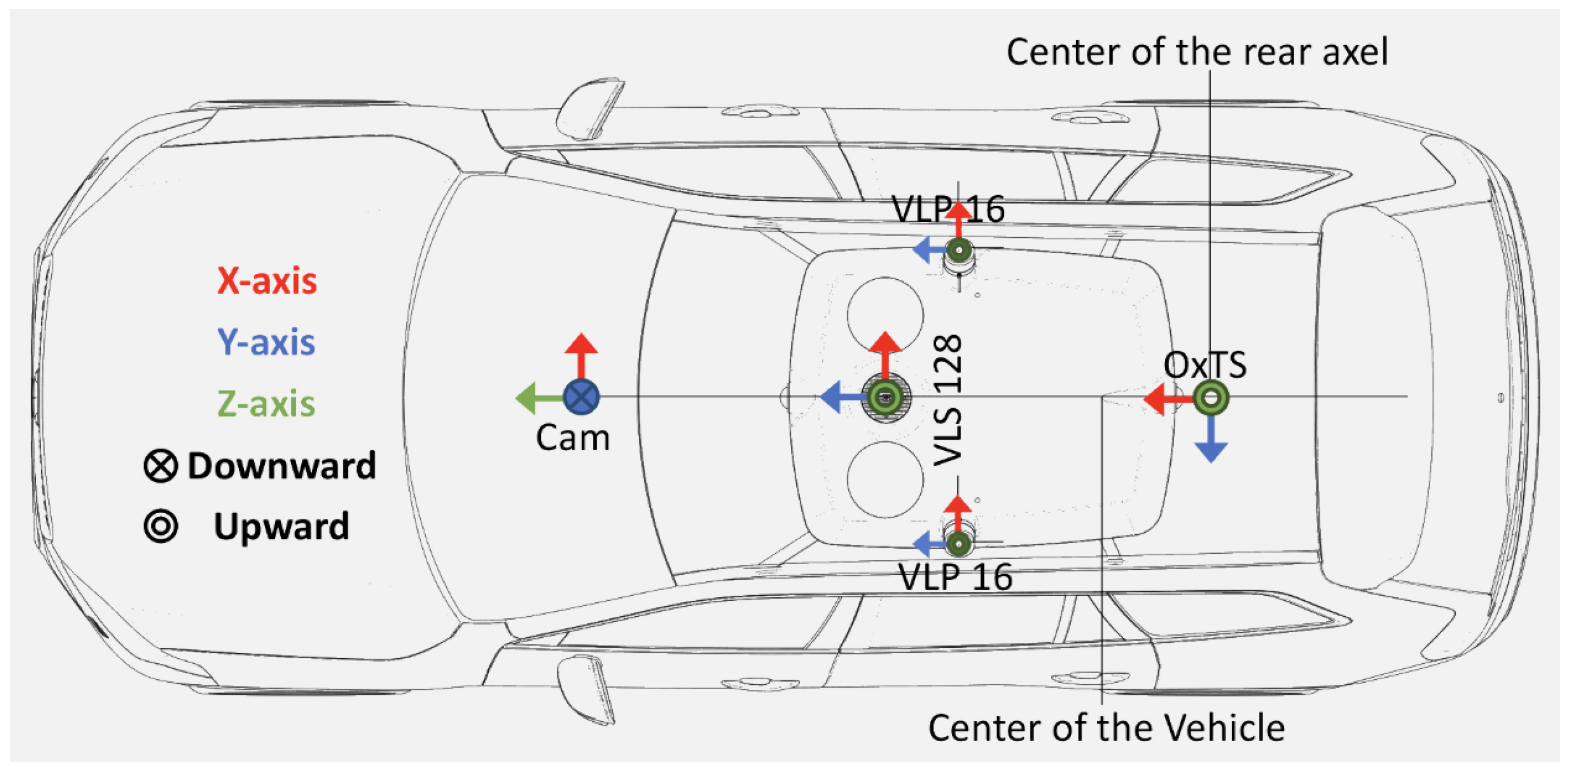

In [1]:
%load_ext autoreload
%autoreload 2
# Import required libraries
import sys
sys.path.append("../")
import os
import numpy as np
import utm
import io
import shutil
import h5py
import json
import matplotlib.pyplot as plt
from PIL import Image
from typing import List
import cv2 
from pyproj import CRS, Transformer
import pandas as pd

# Load customized utility functions
from utils.transformations import rotation_matrix_from_angles, get_yaw_pitch_roll, filter_above_ground, compute_heading
from utils.plot import plot_lidar_camera_oxts
from utils.process import memory_usage

# Load ZOD DevKit
from zod import ZodFrames, ZodSequences, ZodDrives
import zod.constants as constants
from zod.constants import Camera, Lidar, Anonymization, AnnotationProject
from zod.data_classes.ego_motion import OXTS_TIMESTAMP_OFFSET, interpolate_transforms
from zod.data_classes import LidarData
from zod.utils.geometry import transform_points
from zod.visualization.lidar_on_image import get_3d_transform_camera_lidar
from zod.constants import Camera, Lidar
from zod.data_classes.metadata import SequenceMetadata

# Load aerial image download functions
from Map_Downloading.scripts.sweden import sweden_exact_position_image
from Map_Downloading.scripts.sweden import RESOLUTION as sweden_resolution
from Map_Downloading.scripts.france import france_exact_position_image
from Map_Downloading.scripts.france import TRUE_RESOLUTION as france_resolution


# Set matplotlib settings
%matplotlib inline

# NOTE! Set the path to dataset and choose a version
lidar_dataset_root = "/work/vita/datasets/zod"  # your local path to zod "/mnt/data/Work/datasets/zod"
aerial_img_dataset_root = "/work/vita/datasets/zod_crossview_processed_100m"  # your local path to aerial images
version = "full"  # "mini" or "full"



# Load and display sensor frames
sensor_frames = plt.imread('./sensor_frames.png')
plt.figure(figsize=(20, 10))
plt.imshow(sensor_frames)
plt.axis('off')
plt.show()


In [2]:
def approximate_meridian_convergence(lat_deg, lon_deg, central_meridian_deg):
    """
    Approximates the meridian convergence (in degrees) given a point's latitude and longitude,
    and the central meridian of the map projection.

    Args:
        lat_deg (float): Latitude in degrees.
        lon_deg (float): Longitude in degrees.
        central_meridian_deg (float): Central meridian longitude in degrees.

    Returns:
        float: Meridian convergence in degrees.
    """
    lat_rad = np.radians(lat_deg)
    lon_rad = np.radians(lon_deg)
    cm_rad = np.radians(central_meridian_deg)
    gamma_rad = np.arctan(np.tan(lon_rad - cm_rad) * np.sin(lat_rad))
    return np.degrees(gamma_rad)

In [3]:
# initialize ZodDrives
zod_drives = ZodDrives(dataset_root=lidar_dataset_root, version=version)


# get default training and validation splits
training_drives = zod_drives.get_split(constants.TRAIN)
validation_drives = zod_drives.get_split(constants.VAL)

print(f"Number of training drives: {len(training_drives)}")
print(f"Number of validation drives: {len(validation_drives)}")

all_drive_num = list(training_drives) + list(validation_drives)
print(f"Number of total drives: {len(all_drive_num)}")

drives_per_country = {}

for i in range(len(all_drive_num)):
    zod_drive = zod_drives[all_drive_num[i]]
    # zod_drive._metadata = SequenceMetadata("/work/vita/datasets/zod/drives/000000/metadata.json")
    metadata = zod_drive.metadata
    
    if metadata.country_code in drives_per_country:
        drives_per_country[metadata.country_code].append(all_drive_num[i])
    else:
        drives_per_country[metadata.country_code] = [all_drive_num[i]]

for country in drives_per_country.keys():
    print(country, len(drives_per_country[country]))

Loading infos: 0it [00:00, ?it/s]

Number of training drives: 23
Number of validation drives: 6
Number of total drives: 29
SE 24
FR 5


### Use previous and next oxts measure (global positioning) to get current pose (recommended)

drive_idx 000021 Country: SE
Frame 0/1354, Memory Usage: 333.50 MB


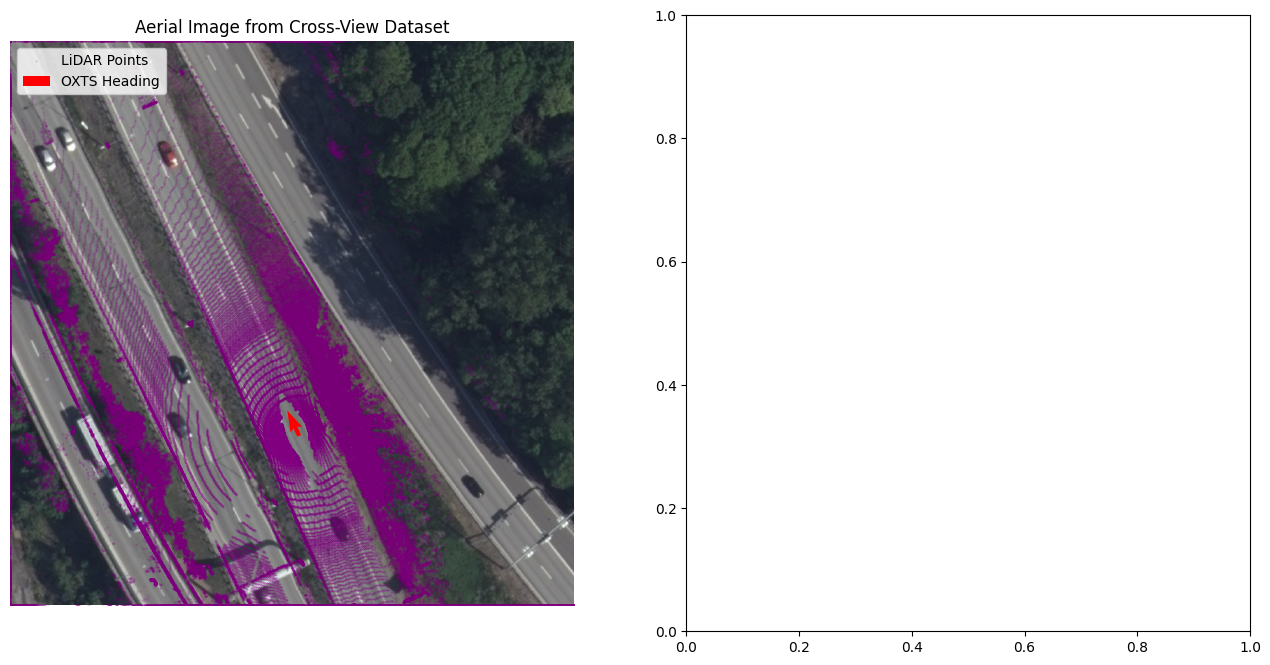

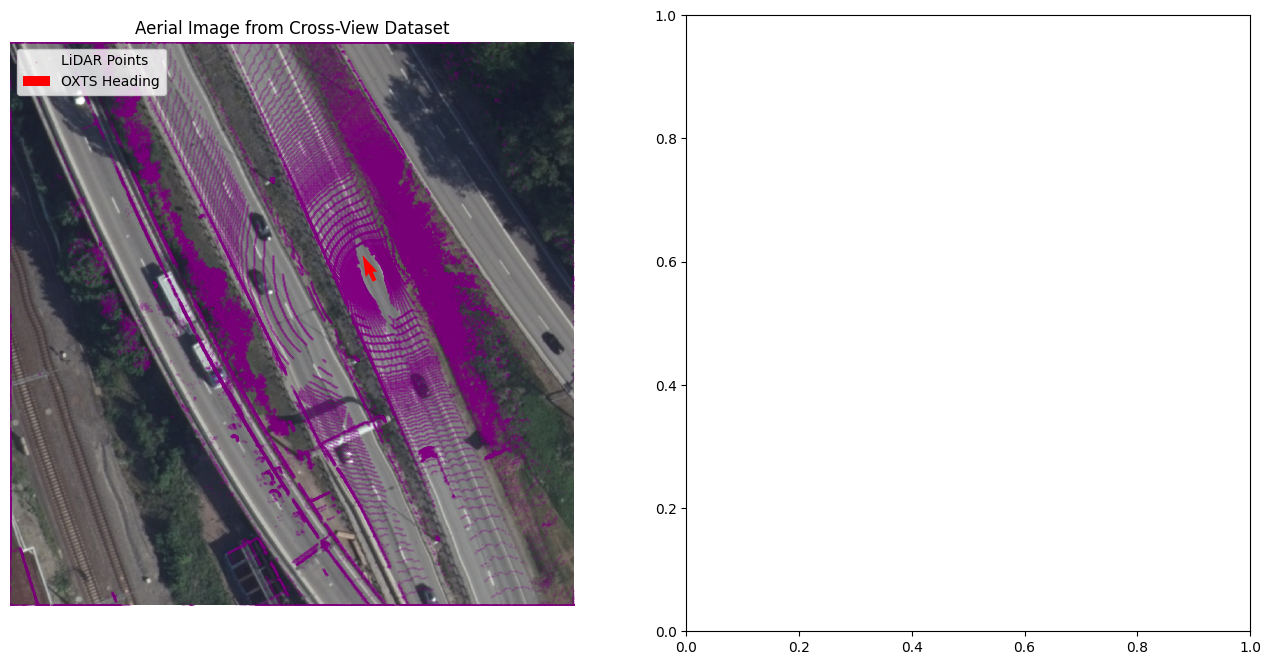

In [4]:
size = 100 # side length (m) of the requested aerial image


# List of drives to process
drive_list = [str(i).zfill(6) for i in range(28)]

drive_list = ['000021']  # Modify as needed

for drive_idx in drive_list:
    drive = zod_drives[drive_idx]
    print('drive_idx', drive_idx, "Country:", drive.metadata.country_code)

    
    # Define Paths
    drive_path = os.path.join(lidar_dataset_root, 'drives', drive_idx)
    aerial_path = os.path.join(aerial_img_dataset_root, "aerial_img")
    # ground_path = os.path.join(aerial_img_dataset_root, "ground_img")

    calibrations = drive.calibration
    T_lidar2oxts = calibrations.lidars[Lidar.VELODYNE].extrinsics.transform

    num_frames = len(drive.info.camera_frames['front_blur'])
    filename = os.path.join(drive_path, "oxts.hdf5")

    # Read HDF5 Data Once
    with h5py.File(filename, "r") as f:
        def recursively_print(name, obj):
            print(name)
        # f.visititems(recursively_print)
        # print('GNSSAntenna/accuracyHeadingAntennas', f['GNSSAntenna/accuracyHeadingAntennas'][()])
        # print('poseSource', f['poseSource'][()])

        orientationMode = f['orientationMode'][()]
        earth_frame_bytes = f['earthFrame'][()]
        earth_frame = b''.join(earth_frame_bytes).decode('utf-8') 

        INSToHostRotation = f['INSToHostRotation'][()]

        datumEllipsoid_bytes = f['datumEllipsoid'][()]
        datumEllipsoid = b''.join(datumEllipsoid_bytes).decode('utf-8') 
        
        lat = f['posLat'][()]
        lon = f['posLon'][()]
        alt = f['posAlt'][()]
        # print(f['heading'][()] )
        yaw = 90 - f['heading'][()] 
        
        pitch = f['pitch'][()]
        roll = f['roll'][()]
        timestamp = OXTS_TIMESTAMP_OFFSET + f['timestamp'][()] + f['leapSeconds'][()][0]
        
    # print('earth_frame', earth_frame)
    # print('datumEllipsoid', datumEllipsoid)
    # print('INSToHostRotation', (INSToHostRotation))
    # print('orientationMode', orientationMode)
    
    heading_difference = []
    T_prev = np.eye(4)


    # for i in range(0, num_frames):
    # for i in range(0, num_frames, num_frames//2):
    for i in range(0,2):
        if i % 100 == 0:
            print(f"Frame {i}/{num_frames}, Memory Usage: {memory_usage():.2f} MB")
            
        ######################################################################
        # MF : filepath to corresponding aerial image in cross view dataset
        temp_filepath_to_aerial_img = drive.info.camera_frames['front_blur'][i].filepath
        temp_filepath_to_aerial_img = temp_filepath_to_aerial_img.replace("zod", "zod_crossview_processed_100m" ).replace("drives","drives/"+drive.metadata.country_code).replace("camera_front_blur", "aerial").replace(".jpg", ".png")
        
        tmp = aerial_img_dataset_root + "/drives/" + drive.metadata.country_code + "/labels.json" 

        with open(tmp, 'r') as f:
            aer_img_data_temp = json.load(f)
            
        aerial_img_data_df = pd.DataFrame(aer_img_data_temp)
        
        # print(drive)
        # print(temp_filepath_to_aerial_img)
        # print(tmp)
        # print(drive.metadata.country_code)
        # print(aerial_img_dataset_root)
        # print(lidar_dataset_root)
        # aerial_img_rel_path = temp_filepath_to_aerial_img.replace(aerial_img_dataset_root+"/", "")
        # cross_view_idx = aerial_img_data_df.loc[(aerial_img_data_df.aerial_image == aerial_img_rel_path)].index.item()
        # print(aerial_img_rel_path)
        # print(cross_view_idx)
        
        
        
        # if drive.metadata.country_code != 'SE':
        #     continue
        if drive_idx not in aerial_img_data_df.drive_idx.unique():
            continue
        ######################################################################

        current_timestamp = drive.info.camera_frames['front_blur'][i].time.timestamp()
        
        # Use np.searchsorted for efficient timestamp lookup
        oxts_idx = np.searchsorted(timestamp, current_timestamp, side='right')

        if oxts_idx == 0 or oxts_idx >= len(timestamp):
            continue  # Skip if no valid index

                
        # Extract previous and next OXTS readings
        lat_prev, lon_prev, alt_prev = lat[oxts_idx - 1], lon[oxts_idx - 1], alt[oxts_idx - 1]
        yaw_prev, pitch_prev, roll_prev = yaw[oxts_idx - 1], pitch[oxts_idx - 1], roll[oxts_idx - 1]
        easting_prev, northing_prev, zone_number_prev, zone_letter_prev = utm.from_latlon(lat_prev, lon_prev)

        lat_next, lon_next, alt_next = lat[oxts_idx], lon[oxts_idx], alt[oxts_idx]
        yaw_next, pitch_next, roll_next = yaw[oxts_idx], pitch[oxts_idx], roll[oxts_idx]
        easting_next, northing_next, zone_number_next, zone_letter_next = utm.from_latlon(lat_next, lon_next)

        gamma_prev = 0
        gamma_next = 0
        if drive.metadata.country_code == 'SE':
            gamma_prev = approximate_meridian_convergence(lat_prev, lon_prev, 15)
            gamma_next = approximate_meridian_convergence(lat_next, lon_next, 15)
        
        yaw_prev += gamma_prev # heading should subtract gamma, hence yaw should be adding 
        yaw_next += gamma_next 


        # Compute previous and next transformation matrices
        T_previous = np.eye(4)
        T_previous[:3, :3] = rotation_matrix_from_angles(
            np.radians(roll_prev), np.radians(pitch_prev), np.radians(yaw_prev), order="ZYX"
        )
        T_previous[:3, 3] = [easting_prev, northing_prev, alt_prev]

        T_next = np.eye(4)
        T_next[:3, :3] = rotation_matrix_from_angles(
            np.radians(roll_next), np.radians(pitch_next), np.radians(yaw_next), order="ZYX"
        )
        T_next[:3, 3] = [easting_next, northing_next, alt_next]
        
        # Interpolate transformation
        interp_factor = (current_timestamp - timestamp[oxts_idx - 1]) / (timestamp[oxts_idx] - timestamp[oxts_idx - 1])
        T_current = interpolate_transforms(T_previous, T_next, interp_factor)
        yaw_oxts, _, _ = get_yaw_pitch_roll(T_current)
        heading_oxts = 90 - np.degrees(yaw_oxts)
        
        
    
        # Process Lidar Data
        pcd = drive.get_compensated_lidar(drive.info.camera_frames['front_blur'][i].time).points
        pcd_utm = transform_points(pcd, T_current @ T_lidar2oxts) 
        # pcd_utm = filter_above_ground(pcd_utm, ground_threshold=1)

        # Compute heading difference
        heading_move = compute_heading(T_prev[0, 3], T_prev[1, 3], T_current[0, 3], T_current[1, 3])

        if i > 0:
            difference = (heading_move - heading_oxts + 180) % 360 - 180
            # print('difference', difference)
            heading_difference.append(difference)

        T_prev = T_current.copy()

        ################################################################################################################
        # MF : Using Zimin Cross-View Dataset 
        ################################################################################################################
        
        # Extract aerial image metadata
        aerial_img_rel_path = temp_filepath_to_aerial_img.replace(aerial_img_dataset_root+"/", "")
        cross_view_idx = aerial_img_data_df.loc[(aerial_img_data_df.aerial_image == aerial_img_rel_path)].index.item()
        aer_img_metadata = aerial_img_data_df.loc[cross_view_idx]
        
        aerial_lat, aerial_lon = aer_img_metadata['aerial_latlon']
        # ground_lat, ground_lon = aer_img_metadata['ground_latlon']
        aerial_easting, aerial_northing, _, _ = utm.from_latlon(aerial_lat, aerial_lon)
        # ground_easting, ground_northing, _, _ = utm.from_latlon(ground_lat, ground_lon)
        # dx_offset = aer_img_metadata['dx']
        # dy_offset = aer_img_metadata['dy']
        aerial_heading = aer_img_metadata['heading']
        # K = aer_img_metadata['K']
        # gamma_aerial = approximate_meridian_convergence(aerial_lat, aerial_lon, 15)
        
        # T_aerial = np.eye(4)
        # T_aerial[:3, :3] = rotation_matrix_from_angles(
        #     np.radians(0), np.radians(0), np.radians(gamma_aerial), order="ZYX"
        # )
        # T_aerial[:3, 3] = [aerial_easting, aerial_northing, 0]
        
        # temp_yaw,_,_ = get_yaw_pitch_roll( T_aerial )
        # print(f"heading_oxts:{90-np.degrees(temp_yaw)}, yaw : {np.degrees(temp_yaw)}, gamma : {gamma_aerial}")

        
        # Load Aerial Image and Resolution
        aerial_img = cv2.imread(temp_filepath_to_aerial_img)
        aerial_img = cv2.cvtColor(aerial_img, cv2.COLOR_BGR2RGB)
        resolution = aer_img_metadata.resolution

        # Plot BEV (Bird’s Eye View) with LiDAR points
        bev_image = np.array(aerial_img)
        H, W = bev_image.shape[:2]
        bev_center = (aerial_easting, aerial_northing) # (T_current[0, 3], T_current[1, 3])
        
        # Transform lidar from UTM to aerial image coordinates : Translate relative to aerial image center
        pcd_relative = pcd_utm[:, :2] - np.array([aerial_easting, aerial_northing])

        # Rotate by aerial heading
        theta = np.radians(-(heading_oxts-aerial_heading)) 
        rotation_matrix = np.array([
            [np.cos(theta), -np.sin(theta)],
            [np.sin(theta), np.cos(theta)]
        ])
        pcd_rotated = pcd_relative @ rotation_matrix.T
        
        # Convert LiDAR points to BEV pixel coordinates
        x_indices = ((pcd_rotated[:, 0]) / resolution + W / 2).astype(int)
        y_indices = H - ((pcd_rotated[:, 1]) / resolution + H / 2).astype(int)
        x_indices, y_indices = np.clip(x_indices, 0, W - 1), np.clip(y_indices, 0, H - 1)

        # # Clip to image bounds
        # x_indices = np.clip(x_indices, 0, W - 1)
        # y_indices = np.clip(y_indices, 0, H - 1)

        # Vehicle position relative to aerial center
        vehicle_relative = np.array([T_current[0, 3] - aerial_easting, 
                                    T_current[1, 3] - aerial_northing])
        vehicle_pixel = vehicle_relative / resolution
        
        vehicle_x = int(W / 2 + vehicle_pixel[0])
        vehicle_y = int(H / 2 - vehicle_pixel[1])
        
        # print('vehicle_pixel', vehicle_pixel[0], -vehicle_pixel[1], "dy/dy_offset", dy_offset, dx_offset, "K", K)
        
        fig, axs = plt.subplots(1,2, figsize=(16, 8))
        axs[0].imshow(bev_image, origin='upper')
        axs[0].scatter(x_indices, y_indices, s=0.1, c='purple', alpha=0.3, label="LiDAR Points")
        # axs[0].quiver(W / 2, H / 2, np.sin(np.radians(heading_move)), np.cos(np.radians(heading_move)), color='cyan', scale=20, label='Movement')
        axs[0].quiver(vehicle_x, vehicle_y, np.sin(np.radians(aerial_heading)), np.cos(np.radians(aerial_heading)), color='r', scale=20, label='OXTS Heading')
        axs[0].legend(loc=2)
        axs[0].axis('off')
        axs[0].set_title('Aerial Image from Cross-View Dataset')
        
        ################################################################################################################
        
        # # Retrieve Aerial Image
        # lat_current, lon_current = utm.to_latlon(T_current[0, 3], T_current[1, 3], zone_number_next, zone_letter_next)
        # if drive.metadata.country_code == 'SE':
        #     aerial_img = sweden_exact_position_image(lat_current, lon_current, size)
        #     resolution = sweden_resolution
        # elif drive.metadata.country_code == 'FR':
        #     aerial_img = france_exact_position_image(lat_current, lon_current, size)
        #     resolution = france_resolution

        # # Plot BEV (Bird’s Eye View) with LiDAR points
        # bev_image = np.array(aerial_img)
        # H, W = bev_image.shape[:2]
        # bev_center = (T_current[0, 3], T_current[1, 3])

        # # Convert LiDAR points to BEV pixel coordinates
        # x_indices = ((pcd_utm[:, 0] - bev_center[0]) / resolution + W / 2).astype(int)
        # y_indices = H - ((pcd_utm[:, 1] - bev_center[1]) / resolution + H / 2).astype(int) # H/2 - (pcd - bev_center) = H/2 - pcd + bev_center
        # x_indices, y_indices = np.clip(x_indices, 0, W - 1), np.clip(y_indices, 0, H - 1)
        
        # axs[1].imshow(bev_image, origin='upper')
        # axs[1].scatter(x_indices, y_indices, s=0.1, c='purple', alpha=0.3, label="LiDAR Points")
        # # plt.quiver(W / 2, H / 2, np.sin(np.radians(heading_move)), np.cos(np.radians(heading_move)), color='cyan', scale=20, label='Movement')
        # axs[1].quiver(W / 2, H / 2, np.sin(np.radians(heading_oxts)), np.cos(np.radians(heading_oxts)), color='r', scale=20, label='OXTS')
        # axs[1].legend(loc=2)
        # axs[1].axis('off')
        # axs[1].set_title('Aerial Image from Map Downloading')
        # plt.savefig(os.path.join(aerial_path, f'frame{i:06}.png'), bbox_inches='tight')
        # fig.show()
        # plt.close()
        
    break
    if int(drive_idx) > 0:
        break
    # print(f"Drive {drive_idx} Completed. Heading Difference Mean: {np.mean(x):.2f}, Median: {np.median(heading_difference):.2f}")

In [5]:
lidar = drive.get_compensated_lidar(
    drive.info.camera_frames['front_blur'][i].time
)

# XYZ
xyz = lidar.points  # (N, 3)

# Intensity: check the actual attribute name once in a Python shell.
# It is commonly 'intensity' or 'intensities'.
intensity = lidar.intensity

In [10]:
intensity.shape, xyz.shape


((263471,), (263471, 3))

In [ ]:
bev_image.max(), bev_image.mean(), bev_image.shape, H , W, aerial_img.shape

In [ ]:
diff = np.array([aerial_easting - T_current[0, 3] , aerial_northing - T_current[1, 3]]) 

In [ ]:
diff

In [ ]:
pcd_utm[:,:2] - np.array([aerial_easting, aerial_northing])

In [ ]:
pcd_utm[:,:2] - np.array([T_current[0, 3] , T_current[1, 3]]) - diff

In [ ]:
fig, axs = plt.subplots(1)
points = pcd_utm[:,:2] - np.array([T_current[0, 3] , T_current[1, 3]])
temp_pcd_rot_pix = ((points - diff) @ rotation_matrix.T / resolution).astype(int)
# temp_pcd_rot_pix = np.clip(temp_pcd_rot_pix, 0, W - 1)

x_ind = np.clip(W//2 + temp_pcd_rot_pix[:,0], 0, W - 1)
y_ind = np.clip(H//2 - temp_pcd_rot_pix[:,1], 0, H - 1)

axs.imshow(bev_image, origin='upper')
axs.scatter(x_ind, y_ind, s=0.1, c='purple', alpha=0.3, label="LiDAR Points")
# axs[0].quiver(W / 2, H / 2, np.sin(np.radians(heading_move)), np.cos(np.radians(heading_move)), color='cyan', scale=20, label='Movement')
axs.quiver(W//2 - diff[0]/resolution, H//2 + diff[1]/resolution , np.sin(np.radians(aerial_heading)), np.cos(np.radians(aerial_heading)), color='r', scale=20, label='OXTS Heading')
axs.legend(loc=2)
axs.axis('off')
axs.set_title('Aerial Image from Cross-View Dataset')

In [ ]:
W//2 + temp_pcd_rot_pix[:,0]

In [ ]:
bev_image

In [ ]:
drive = zod_drives[5]

In [ ]:
drive.metadata.country_code

In [ ]:
drive.info.camera_frames["front_blur"][7]

In [ ]:
aer = cv2.imread("/work/vita/datasets/zod_crossview_processed_100m/drives/SE/000005/aerial/000005_romeo_2023-03-02T07:44:47.680802Z.png")
aer = cv2.cvtColor(aer, cv2.COLOR_BGR2RGB)
plt.imshow(np.array(aer), origin='upper')